In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("ai_student_impact_dataset.csv")

In [3]:
y = df["Burnout_Risk_Level"]
X = df.drop(columns="Burnout_Risk_Level")


In [4]:
#pip install scikit-learn

In [5]:
from sklearn.model_selection import train_test_split

# Separizziamo X (le feature) e y (il target, es. 'Burnout_Risk_Level')
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2,          # Scegliamo il 20% dei dati per il test set e l'80% per il train   
    random_state=42,        # Inseriamo un seme casuale fisso per rendere i risultati riproducibili
    stratify=y              # FONDAMENTALE: Mantiene le stesse proporzioni delle classi del target sia in train che in test
)

In [6]:
target_map = {'Low': 0, 'Medium': 1, 'High': 2}   # random forest e xgboost lavorano meglio se y è mappata
y_train = y_train.map(target_map)
y_test = y_test.map(target_map)

In [7]:
X_train.drop(columns=['Student_ID'], inplace=True, errors='ignore')
X_test.drop(columns=['Student_ID'], inplace=True, errors='ignore') # colonna inutile

In [8]:
lista= y_train.unique()
print(lista.tolist()) # 5 diversi valori 

[2, 1, 0]


In [9]:
lista= X_train["Year_of_Study"].unique()
print(lista.tolist()) # 5 diversi valori 

['Junior', 'Sophomore', 'Graduate', 'Senior', 'Freshman']


In [10]:
lista= X_train["Prompt_Engineering_Skill"].unique()
print(lista.tolist())

['Beginner', 'Advanced', 'Intermediate']


In [11]:
y_test.info()

<class 'pandas.Series'>
Index: 10000 entries, 18437 to 43395
Series name: Burnout_Risk_Level
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 156.2 KB


In [12]:
# mappa_skills = {'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}   #lable encoding risponde alla presenza di un ordinamento
# X_train['Prompt_Engineering_Skill_Num'] = X_train['Prompt_Engineering_Skill'].map(mappa_skills)
# X_test['Prompt_Engineering_Skill_Num'] = X_test['Prompt_Engineering_Skill'].map(mappa_skills)

X_train = X_train.drop('Prompt_Engineering_Skill', axis=1)
X_test = X_test.drop('Prompt_Engineering_Skill', axis=1)

In [13]:
X_train = X_train.drop('Primary_Use_Case', axis=1)
X_test = X_test.drop('Primary_Use_Case', axis=1)

    # X_train = pd.get_dummies(X_train, columns=['Primary_Use_Case'], dtype=int)   
    # X_test = pd.get_dummies(X_test, columns=['Primary_Use_Case'], dtype=int) 

    # one hot encoding, non c'era ordinamento o relazione diretta con la y però 
    # interagisce con altre feature quindi le conservo per un eventuale feature engeneering 

    # e comunque... si fa sempre in tempo ad eliminare

In [14]:
    # X_train = pd.get_dummies(X_train, columns=['Major_Category'], dtype=int)
    # X_test = pd.get_dummies(X_test, columns=['Major_Category'], dtype=int)

X_train.drop(columns=['Tool_Diversity'], inplace=True, errors='ignore')
X_test.drop(columns=['Tool_Diversity'], inplace=True, errors='ignore')

X_train.drop(columns=['Primary_Use_Case'], inplace=True, errors='ignore')
X_test.drop(columns=['Primary_Use_Case'], inplace=True, errors='ignore')

X_train.drop(columns=['Major_Category'], inplace=True, errors='ignore')
X_test.drop(columns=['Major_Category'], inplace=True, errors='ignore')

X_train.drop(columns=['Institutional_Policy'], inplace=True, errors='ignore')
X_test.drop(columns=['Institutional_Policy'], inplace=True, errors='ignore')

In [15]:
    # X_train = pd.get_dummies(X_train, columns=['Institutional_Policy'], dtype=int)
    # X_test = pd.get_dummies(X_test, columns=['Institutional_Policy'], dtype=int)


# presenta un legame indiretto con "livelli di burnout" attraverso "l'ansia da esame "

In [16]:
X_test.info()   # Perceived_AI_Dependency- Tool_Diversity    /     Institutional_Policy  ( **dove è bannata** prodotto di ore ai - Anxiety_Level_During_Exams - Paid_Subscription )  / 

<class 'pandas.DataFrame'>
Index: 10000 entries, 18437 to 43395
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year_of_Study               10000 non-null  str    
 1   Pre_Semester_GPA            10000 non-null  float64
 2   Weekly_GenAI_Hours          10000 non-null  float64
 3   Paid_Subscription           10000 non-null  bool   
 4   Traditional_Study_Hours     10000 non-null  float64
 5   Perceived_AI_Dependency     10000 non-null  int64  
 6   Anxiety_Level_During_Exams  10000 non-null  int64  
 7   Post_Semester_GPA           10000 non-null  float64
 8   Skill_Retention_Score       10000 non-null  float64
dtypes: bool(1), float64(5), int64(2), str(1)
memory usage: 712.9 KB


In [17]:
# pip install category-encoders

scelgo di fare target encoding sulla colonna "Year_of_Study", in funzione delle osservazioni in fase di analisi data.
RECAP da analisi dati:
I Freshman (1) iniziano con un livello di burnout alto (il rosso sfiora il 28%). Questo è fisiologico e descrive lo shock da inserimento universitario, le prime sessioni d'esame e il cambio di metodo di studio.

Nei Sophomore (2) e ancora di più nei Junior (3), la fascia rossa si restringe visibilmente, toccando il punto più basso (sotto il 20%). Parallelamente, nei Junior la fascia verde (Low) raggiunge la sua massima espansione (oltre il 40%).

La fascia rossa (High) torna a espandersi, superando nuovamente il 20%.

In [18]:
# 1. Creiamo una copia temporanea del train per calcolare le frequenze
df_temp = X_train.copy()
df_temp['target_temp'] = y_train

# 2. Calcoliamo la tabella delle probabilità per ogni anno di studio
prob_table = pd.crosstab(df_temp['Year_of_Study'], df_temp['target_temp'], normalize='index')
prob_table.columns = [f'Year_of_Study_Prob_{classe}' for classe in prob_table.columns]

# 3. Mappiamo le probabilità creando i nuovi DataFrame codificati
X_train_encoded = X_train.merge(prob_table, on='Year_of_Study', how='left').set_index(X_train.index)
X_test_encoded = X_test.merge(prob_table, on='Year_of_Study', how='left').set_index(X_test.index)

# 4. Gestione di eventuali valori mancanti nel Test Set
for col in prob_table.columns:
    # Rimuoviamo il prefisso per trovare il nome originale della classe (es. 0, 1, 2 oppure 'Low', 'Medium', 'High')
    nome_classe_originale = col.replace('Year_of_Study_Prob_', '')
    
    # Se le classi in y_train sono diventate numeriche (0, 1, 2) a causa di un mapping precedente,
    # convertiamo il nome della classe in intero se è composto da sole cifre
    if str(nome_classe_originale).isdigit():
        nome_classe_originale = int(nome_classe_originale)
        
    prob_globale = (y_train == nome_classe_originale).mean()
    X_test_encoded[col] = X_test_encoded[col].fillna(prob_globale)

# ==============================================================================
# 5. PASSO FONDAMENTALE: AGGIORNARE LE VARIABILI ORIGINALI E RIMUOVERE LA VECCHIA COLONNA
# ==============================================================================
# Sovrascriviamo X_train e X_test con i nuovi DataFrame che contengono le probabilità
X_train = X_train_encoded.copy()
X_test = X_test_encoded.copy()


In [19]:
# 5. Eliminiamo la vecchia colonna categorica 'Year_of_Study' se presente
if 'Year_of_Study' in X_train.columns:
    X_train.drop(columns=['Year_of_Study'], inplace=True)
if 'Year_of_Study' in X_test.columns:
    X_test.drop(columns=['Year_of_Study'], inplace=True)

# Verifica finale per essere sicuri al 100%
print("Colonne create con successo:")
print([c for c in X_train.columns if 'Year_of_Study_Prob' in c])

Colonne create con successo:
['Year_of_Study_Prob_0', 'Year_of_Study_Prob_1', 'Year_of_Study_Prob_2']


**fine preparazione colonne**

inizio addestramento del modello (non ho scalato i valori perchè userò un modello di random forest)

# piano: valutare random forest e xgboost  
fase 1) trovare gli iperparametri migliori per  random forest   (**fatto**)

fase 2) trovare gli iperparametri migliori per  xgboost 

fase 3) addestrare i modelli e confrontarli 

In [20]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Inizializziamo il modello base
# Usiamo random_state per garantire la riproducibilità degli split interni della cross-validation
rf_base = RandomForestClassifier(random_state=42)

# 2. Definiamo la griglia degli iperparametri da testare
# NOTA: Puoi stringere o allargare questi range in base alla potenza di calcolo della tua macchina
param_grid = {
    'n_estimators': [100, 150 ],          
    'max_depth': [7, 10, 20],          # Massima profondità di ogni albero (None = cresce al massimo)
    'min_samples_split': [ 5, 10],          # Numero minimo di campioni richiesti per sdoppiare un nodo
    'min_samples_leaf': [4],            # Numero minimo di campioni richiesti in una foglia (nodo finale)
    'criterion': ['gini']          # Funzione per misurare la qualità dello split
}

# 3. Configuriama la Grid Search
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,                     
    scoring='accuracy',       # da valutare 'f1_macro' o 'roc_auc' se le tue classi sono molto sbilanciate
    n_jobs=-1,               
    verbose=2                 # Stampa a schermo i progressi 
)

# 4. Avviamo la ricerca sul set di addestramento
grid_search.fit(X_train, y_train)

# ==============================================================================
# RISULTATI DELLA RICERCA
# ==============================================================================

print("\n--- Risultati della Grid Search ---")
print(f"Miglior punteggio ottenuto (CV Score): {grid_search.best_score_:.4f}")
print("Migliori iperparametri trovati:")
for param, value in grid_search.best_params_.items():
    print(f"  -> {param}: {value}")


Fitting 5 folds for each of 12 candidates, totalling 60 fits


KeyboardInterrupt: 

# VALORI TROVATI PRIMA DELLA PULIZIA DELLE COLONNE POCO INFLUENTI

param_grid = {
    'n_estimators': [100, 150, 200 ],    

    'max_depth': [ 10, 20, 30],          # Massima profondità di ogni albero (None = cresce al massimo)

    'min_samples_split': [2, 5, 10],          # Numero minimo di campioni richiesti per sdoppiare un nodo

    'min_samples_leaf': [4],            # Numero minimo di campioni richiesti in una foglia (nodo finale)

    'criterion': ['gini']          # Funzione per misurare la qualità dello split

}


--- **Risultati della Grid Search** ---
Miglior punteggio ottenuto (CV Score): 0.5362

Migliori iperparametri trovati per random foreset:

  -> criterion: gini

  -> max_depth: 10

  -> min_samples_leaf: 4

  -> min_samples_split: 2

  -> n_estimators: 100

**miglior risultato ottenuto:**
Accuratezza del modello (Solo Pulizia Colonne): 0.5343

--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---
              precision    recall  f1-score   support

     Low (0)       0.54      0.49      0.51      3274
  Medium (1)       0.49      0.62      0.54      4229
    High (2)       0.67      0.46      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.57      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000

# VALORI TROVATI DOPO DELLA PULIZIA DELLE COLONNE POCO INFLUENTI


# addestramento del random forest con gli iperparametri trovati

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 1. Istanziamo il modello con gli iperparametri ottimi trovati
# Aggiungiamo random_state=42 per garantire la riproducibilità dei risultati
best_rf = RandomForestClassifier(
    criterion='gini',
    max_depth=7,            # Modificato da 10 a 7
    min_samples_leaf=4,
    min_samples_split=10,   # Modificato da 2 a 10
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Sfrutta tutti i core della CPU per velocizzare l'addestramento
)

# 2. Addestriamo il modello sul set di train (che include il tuo Target Encoding)
best_rf.fit(X_train, y_train)

# 3. Valutiamo le performance sul set di test per verificare che non ci sia overfitting
y_pred = best_rf.predict(X_test)

# Stampiamo i risultati finali
print(f"Accuratezza finale sul Test Set: {accuracy_score(y_test, y_pred):.4f}\n")
print("--- Report di Classificazione Completo ---")
print(classification_report(y_test, y_pred))

Accuratezza finale sul Test Set: 0.5288

--- Report di Classificazione Completo ---
              precision    recall  f1-score   support

           0       0.54      0.47      0.50      3274
           1       0.48      0.62      0.54      4229
           2       0.66      0.45      0.53      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.51      0.53     10000
weighted avg       0.55      0.53      0.53     10000



PRIMA della pulizia delle colonne  **Con un'accuratezza del 53.05% su un problema a tre classi (casuale su tre classi = 33%), il modello ha catturato dei pattern utili, ma i dati mostrano che fa fatica a distinguere nettamente tra le classi adiacenti.**

**burnout High: ha una precision molto alta (67%) ma una recall bassa (45%). Questo significa che quando il modello si sbilancia a dire "Rischio Alto", ci indovina quasi sempre, ma si perde per strada più della metà dei veri casi ad alto rischio**



ricorda il map 
'Low': 0, 'Medium': 1, 'High': 2

# --------
# da fare ....

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

# Poiché abbiamo un problema a 3 classi (Low, Medium, High), impostiamo l'objective corretto
xgb_base = XGBClassifier(
    objective='multi:softprob', 
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='mlogloss'
)

# 2. Definiamo la griglia degli iperparametri per XGBoost
# Questa selezione è ottimizzata per trovare un buon bilanciamento senza andare in overfitting
param_grid = {
    'n_estimators': [100, 150,  200],           # Numero di alberi sequenziali
    'max_depth': [3, 5, 7],               # Profondità degli alberi (XGBoost preferisce alberi più bassi di RF)
    'learning_rate': [0.01, 0.05, 0.1],    # Passo di apprendimento (regola l'impatto di ogni nuovo albero)
    'subsample': [0.6 ,0.8],              # Percentuale di dati da campionare per ogni albero
    'colsample_bytree': [0,4, 0.7]        # Percentuale di feature da campionare per ogni albero
}

# 3. Configuriama la Grid Search con 5-Fold Cross-Validation
grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=5,                                 # Sdoppia il train in 5 parti per convalidare i punteggi
    scoring='accuracy',                   # Puoi usare 'f1_macro' se le classi sono sbilanciate
    n_jobs=-1,                            # Sfrutta tutti i core della CPU in parallelo
    verbose=2                             # Mostra i log dell'avanzamento dei calcoli
)

# 4. Avviamo l'addestramento sui dati
# NOTA: Assicurati che X_train contenga solo colonne numeriche (dopo i tuoi passaggi di Target Encoding)
grid_search_xgb.fit(X_train, y_train)


# ==============================================================================
# STAMPA DEI RISULTATI
# ==============================================================================
print("\n--- Risultati della Grid Search con XGBoost ---")
print(f"Miglior Accuratezza in Cross-Validation: {grid_search_xgb.best_score_:.4f}")
print("Migliori Iperparametri Trovati:")
for param, value in grid_search_xgb.best_params_.items():
    print(f"  -> {param}: {value}")

# 5. Estraiamo il modello migliore e già pronto
best_xgb_model = grid_search_xgb.best_estimator_

Fitting 5 folds for each of 162 candidates, totalling 810 fits


c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
270 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
270 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Anna\Desktop\progetto con Gabriele\AI_Impact_on_Students\.venv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\Anna\De


--- Risultati della Grid Search con XGBoost ---
Miglior Accuratezza in Cross-Validation: 0.5372
Migliori Iperparametri Trovati:
  -> colsample_bytree: 0.7
  -> learning_rate: 0.05
  -> max_depth: 5
  -> n_estimators: 100
  -> subsample: 0.6


In [ ]:
lista = y_test.unique()
print(lista)  # l'ordine è corretto !! (controllato)

[1 0 2]


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
best_xgb = XGBClassifier(
    objective='multi:softprob',     # Specifica che è un problema multi-classe probabilistico
    eval_metric='mlogloss',         # Metrica di valutazione interna
    colsample_bytree=0.7,           # Iperparametri ottimi trovati dalla tua Grid Search
    learning_rate=0.1,
    max_depth=3,
    n_estimators=100,
    subsample=0.6,
    random_state=42,                # Per rendere i risultati riproducibili
    n_jobs=-1                       # Sfrutta al massimo la CPU
)

best_xgb.fit(X_train, y_train)

y_pred_xgb = best_xgb.predict(X_test)

# Definizione dei nomi delle classi per rendere il report auto-esplicativo
target_names = ['Low (0)', 'Medium (1)', 'High (2)']

print(f"Accuratezza finale di XGBoost sul Test Set: {accuracy_score(y_test, y_pred_xgb):.4f}\n")
print("--- REPORT DI CLASSIFICAZIONE COMPLETO (XGBOOST) ---")
print(classification_report(y_test, y_pred_xgb, target_names=target_names))

Accuratezza finale di XGBoost sul Test Set: 0.5320

--- REPORT DI CLASSIFICAZIONE COMPLETO (XGBOOST) ---
              precision    recall  f1-score   support

     Low (0)       0.54      0.48      0.51      3274
  Medium (1)       0.48      0.61      0.54      4229
    High (2)       0.66      0.47      0.55      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



--- Report di Classificazione Completo (random forest) ---
              precision    recall  f1-score   support

           0       0.54      0.47      0.50      3274
           1       0.48      0.62      0.54      4229
           2       0.67      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000

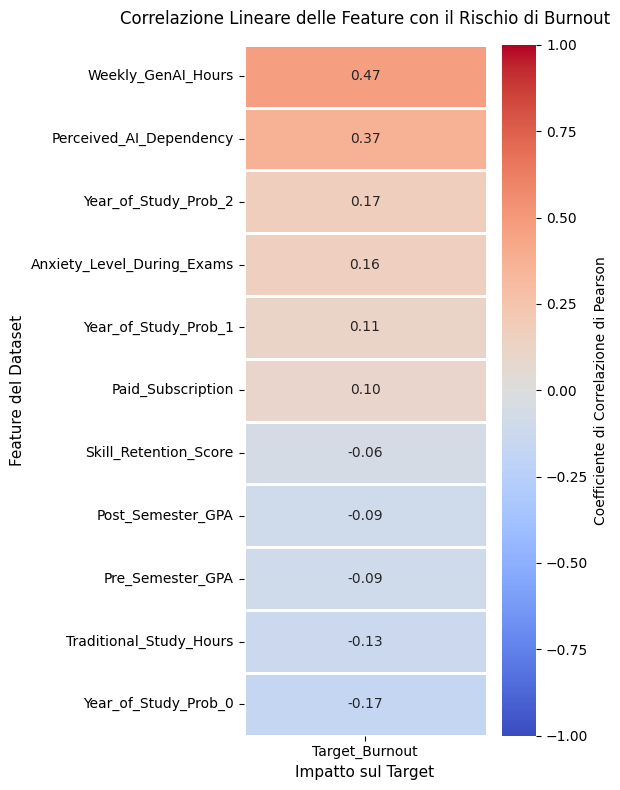

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Creiamo il DataFrame temporaneo unendo Feature e Target
df_corr = X_train.copy()

if y_train.dtype == 'object' or y_train.dtype.name == 'category':
    target_map = {'Low': 0, 'Medium': 1, 'High': 2}
    df_corr['Target_Burnout'] = y_train.map(target_map)
else:
    df_corr['Target_Burnout'] = y_train

# 2. Calcoliamo la matrice ed estraiamo solo la colonna del Target
# Escludiamo l'auto-correlazione del Target con se stesso (che sarebbe 1.0)
correlazione_target = df_corr.corr(method='pearson')[['Target_Burnout']].drop(index='Target_Burnout')

# Ordiniamo i valori in modo decrescente per un impatto visivo immediato
correlazione_target = correlazione_target.sort_values(by='Target_Burnout', ascending=False)

# 3. Disegnamo la heatmap a colonna singola
plt.figure(figsize=(6, 8))
sns.heatmap(
    correlazione_target,
    annot=True,               # Mostra il coefficiente numerico
    fmt=".2f",                # Arrotonda a 2 decimali
    cmap="coolwarm",          # Rosso = aumenta il burnout, Blu = lo diminuisce
    vmin=-1, vmax=1,          # Limiti della scala di correlazione
    linewidths=1,
    cbar_kws={"label": "Coefficiente di Correlazione di Pearson"}
)

# 4. Personalizzazione estetica
plt.title("Correlazione Lineare delle Feature con il Rischio di Burnout", fontsize=12, pad=15)
plt.ylabel("Feature del Dataset", fontsize=11)
plt.xlabel("Impatto sul Target", fontsize=11)

plt.tight_layout()
plt.show()

**dalla colonna delle correlazioni tra le feature e y_train è emerso che ci sono molte feature che sono minimamente correlate con la y_train, quindi potenzialmente poco importanti al fin dell'addestramento. Analisi con la PCA ha confermato che ci sono colonne che creano rumore. La PCA dopo esser stata adoperata ha portato il modello del random forest a migliorare le recall di tutte e tre le classi**

# valuto di migliorare il modello agendo sulle feature:
- elimino le colonne poco significative per eliminare il rumore di fondo
- voglio aggiungere features  con il features engeneering (dopo) 

In [ ]:
    # # 1. Definiamo la lista delle colonne da rimuovere
    # colonne_da_droppare = [
    #     "Primary_Use_Case_Direct_Answer_Generation",
    #     "Prompt_Engineering_Skill_Num",
    #     "Tool_Diversity",
    #     "Primary_Use_Case_Ideation",
    #     "Major_Category_Business",
    #     "Primary_Use_Case_Summarizing_Reading",
    #     "Major_Category_Arts",
    #     "Major_Category_Medical",
    #     "Primary_Use_Case_Copywriting/Drafting"
    # ]

    # # 2. Rimuoviamo le colonne da X_train e X_test
    # # errors='ignore' serve a evitare che il codice si blocchi nel caso in cui tu abbia già cancellato una di queste colonne in precedenza
    # X_train = X_train.drop(columns=colonne_da_droppare, errors='ignore')
    # X_test = X_test.drop(columns=colonne_da_droppare, errors='ignore')

In [ ]:
    # # 1. Istanziamo il secondo modello con gli iperparametri ottimi
    # # Lo assegniamo al nome richiesto: rf_pulizia_colonne
    # rf_pulizia_colonne = RandomForestClassifier(
    #     criterion='gini',
    #     max_depth=10,
    #     min_samples_leaf=4,
    #     min_samples_split=2,
    #     n_estimators=100,
    #     random_state=42,
    #     n_jobs=-1  # Sfrutta tutti i core della CPU per velocizzare l'addestramento
    # )

    # # 2. Addestriamo il modello sui dati TRADIZIONALI (senza PCA, ma con le colonne droppate)
    # rf_pulizia_colonne.fit(X_train, y_train)

    # # 3. Effettuiamo le predizioni sul test set tradizionale
    # y_pred_pulizia = rf_pulizia_colonne.predict(X_test)

    # # 4. Valutiamo le performance per il confronto
    # target_names = ['Low (0)', 'Medium (1)', 'High (2)']

    # print(f"Accuratezza del modello (Solo Pulizia Colonne): {accuracy_score(y_test, y_pred_pulizia):.4f}\n")
    # print("--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---")
    # print(classification_report(y_test, y_pred_pulizia, target_names=target_names))

Accuratezza del modello (Solo Pulizia Colonne): 0.5326

--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---
              precision    recall  f1-score   support

     Low (0)       0.54      0.48      0.51      3274
  Medium (1)       0.48      0.62      0.54      4229
    High (2)       0.67      0.46      0.55      2497

    accuracy                           0.53     10000
   macro avg       0.57      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000



--- Report di Classificazione Completo (random forest) ---
              precision    recall  f1-score   support

           0       0.54      0.47      0.50      3274
           1       0.48      0.62      0.54      4229
           2       0.67      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000

In [ ]:
    # policy_features_list = [
    #     "Institutional_Policy_Strict_Ban",
    #     "Primary_Use_Case_Debugging/Troubleshooting",
    #     "Institutional_Policy_Allowed_With_Citation",
    #     "Institutional_Policy_Actively_Encouraged"
    # ]
    # # 2. Rimuoviamo le colonne da X_train e X_test
    # # errors='ignore' serve a evitare che il codice si blocchi nel caso in cui tu abbia già cancellato una di queste colonne in precedenza
    # X_train = X_train.drop(columns=policy_features_list, errors='ignore')
    # X_test = X_test.drop(columns=policy_features_list, errors='ignore')

In [ ]:
    # # 1. Istanziamo il secondo modello con gli iperparametri ottimi
    # # Lo assegniamo al nome richiesto: rf_pulizia_colonne_2 
    # rf_pulizia_colonne_2 = RandomForestClassifier(
    #     criterion='gini',
    #     max_depth=10,
    #     min_samples_leaf=4,
    #     min_samples_split=2,
    #     n_estimators=100,
    #     random_state=42,
    #     n_jobs=-1  # Sfrutta tutti i core della CPU per velocizzare l'addestramento
    # )

    # # 2. Addestriamo il modello sui dati TRADIZIONALI (senza PCA, ma con le colonne droppate)
    # rf_pulizia_colonne_2 .fit(X_train, y_train)

    # # 3. Effettuiamo le predizioni sul test set tradizionale
    # y_pred_pulizia = rf_pulizia_colonne_2 .predict(X_test)

    # # 4. Valutiamo le performance per il confronto
    # target_names = ['Low (0)', 'Medium (1)', 'High (2)']

    # print(f"Accuratezza del modello (Solo Pulizia Colonne): {accuracy_score(y_test, y_pred_pulizia):.4f}\n")
    # print("--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---")
    # print(classification_report(y_test, y_pred_pulizia, target_names=target_names))

Accuratezza del modello (Solo Pulizia Colonne): 0.5294

--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---
              precision    recall  f1-score   support

     Low (0)       0.54      0.49      0.51      3274
  Medium (1)       0.48      0.61      0.54      4229
    High (2)       0.66      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.54      0.53      0.53     10000



In [ ]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 40000 entries, 1497 to 11196
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Pre_Semester_GPA            40000 non-null  float64
 1   Weekly_GenAI_Hours          40000 non-null  float64
 2   Paid_Subscription           40000 non-null  bool   
 3   Traditional_Study_Hours     40000 non-null  float64
 4   Perceived_AI_Dependency     40000 non-null  int64  
 5   Anxiety_Level_During_Exams  40000 non-null  int64  
 6   Post_Semester_GPA           40000 non-null  float64
 7   Skill_Retention_Score       40000 non-null  float64
 8   Major_Category_Humanities   40000 non-null  int64  
 9   Major_Category_STEM         40000 non-null  int64  
 10  Year_of_Study_Prob_0        40000 non-null  float64
 11  Year_of_Study_Prob_1        40000 non-null  float64
 12  Year_of_Study_Prob_2        40000 non-null  float64
 13  Total_Study_Hours           40000 non-null  

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Definiamo una funzione per applicare lo stesso Feature Engineering a entrambi i dataset
def applica_feature_engineering(df):
    # Creiamo una copia per sicurezza
    df_nuovo = df.copy()
    # 1. ORE TOTALI DI STUDIO
    df_nuovo['Total_Study_Hours'] = df_nuovo['Traditional_Study_Hours'] + df_nuovo['Weekly_GenAI_Hours']
        # 2. RAPPORTO GENAI SUL TOTALE (Proporzione di utilizzo dell'IA)
    # Aggiungiamo 1e-5 (un numero piccolissimo) al denominatore per evitare divisioni per zero
    df_nuovo['GenAI_Study_Ratio'] = df_nuovo['Weekly_GenAI_Hours'] / (df_nuovo['Total_Study_Hours'] + 1e-5)
    
    df_nuovo['Study_Efficiency_Index'] = df_nuovo['Skill_Retention_Score'] / scaler.fit_transform(df_nuovo[['Total_Study_Hours']])["Total_Study_Hours"] 

    # Se la ritenzione è 100, la difficoltà è 1. Se la ritenzione è 20, la difficoltà è 81.
    df_nuovo['Cognitive_Load_Score'] = df_nuovo['Traditional_Study_Hours'] * (101 - df_nuovo['Skill_Retention_Score'])

    return df_nuovo

# Applichiamo il Feature Engineering a Train e Test set
X_train = applica_feature_engineering(X_train)
X_test = applica_feature_engineering(X_test)


# Verifica visiva delle nuove colonne create
print("Nuove colonne inserite nel dataset:")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

le colonne Total_Study_Hours e GenAI_Study_Ratio resentano correlazione rispettivamente di 0.36 e 0.42 rispettivamente


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
# 1. Istanziamo il secondo modello con gli iperparametri ottimi
# Lo assegniamo al nome richiesto: rf_feature_eng 
rf_feature_eng = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_leaf=4,
    min_samples_split=2,
    n_estimators=100,
    random_state=42,
    n_jobs=-1  # Sfrutta tutti i core della CPU per velocizzare l'addestramento
)

# 2. Addestriamo il modello sui dati TRADIZIONALI (senza PCA, ma con le colonne droppate)
rf_feature_eng .fit(X_train, y_train)

# 3. Effettuiamo le predizioni sul test set tradizionale
y_pred_pulizia = rf_feature_eng .predict(X_test)

# 4. Valutiamo le performance per il confronto
target_names = ['Low (0)', 'Medium (1)', 'High (2)']

print(f"Accuratezza del modello (rf_feature_eng): {accuracy_score(y_test, y_pred_pulizia):.4f}\n")
print("--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---")
print(classification_report(y_test, y_pred_pulizia, target_names=target_names))

Accuratezza del modello (Solo Pulizia Colonne): 0.5294

--- REPORT DI CLASSIFICAZIONE (RF PULIZIA COLONNE) ---
              precision    recall  f1-score   support

     Low (0)       0.54      0.49      0.51      3274
  Medium (1)       0.48      0.61      0.54      4229
    High (2)       0.66      0.45      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.56      0.52      0.53     10000
weighted avg       0.54      0.53      0.53     10000



     Low (0)       0.54      0.49      0.51      3274
  Medium (1)       0.49      0.62      0.54      4229
    High (2)       0.67      0.46      0.54      2497

    accuracy                           0.53     10000
   macro avg       0.57      0.52      0.53     10000
weighted avg       0.55      0.53      0.53     10000

# StackingClassifier

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ==============================================================================
# FIRENWALL DI SICUREZZA: PULIZIA DATI DA INF E NAN
# ==============================================================================
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.mean())
X_test = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_test.mean())

if y_train.dtype == 'object' or y_train.dtype.name == 'category':
    target_map = {'Low': 0, 'Medium': 1, 'High': 2}
    y_train = y_train.map(target_map)
    y_test = y_test.map(target_map)

# ==============================================================================
# ARCHITETTURA STACKING
# ==============================================================================
base_models = [
    ('rf_pulizia', RandomForestClassifier(
        criterion='gini', max_depth=10, min_samples_leaf=4, 
        min_samples_split=2, n_estimators=100, random_state=42, n_jobs=-1
    )),
    ('logistic_reg', make_pipeline(
        StandardScaler(), 
        LogisticRegression(multi_class='multinomial', max_iter=1000, random_state=42)
    ))
]


meta_model = LogisticRegression(random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,          
    n_jobs=-1,
    passthrough=False 
)

print("Addestramento dello Stacking Classifier in corso...")
stacking_model.fit(X_train, y_train)

# Predizione sul test set
y_pred_stacking = stacking_model.predict(X_test)

# Report finale
target_names = ['Low (0)', 'Medium (1)', 'High (2)']
print(f"Accuratezza dello Stacking Classifier: {accuracy_score(y_test, y_pred_stacking):.4f}\n")
print("--- REPORT DI CLASSIFICAZIONE (STACKING MODEL) ---")
print(classification_report(y_test, y_pred_stacking, target_names=target_names))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'